In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/kaggle/input/datasets/anthonytherrien/restaurant-revenue-prediction-dataset/restaurant_data.csv")

In [3]:
print(df)

                 Name  Location   Cuisine  Rating  Seating Capacity  \
0        Restaurant 0     Rural  Japanese     4.0                38   
1        Restaurant 1  Downtown   Mexican     3.2                76   
2        Restaurant 2     Rural   Italian     4.7                48   
3        Restaurant 3     Rural   Italian     4.4                34   
4        Restaurant 4  Downtown  Japanese     4.9                88   
...               ...       ...       ...     ...               ...   
8363  Restaurant 8363  Suburban    Indian     3.4                54   
8364  Restaurant 8364     Rural    Indian     3.7                49   
8365  Restaurant 8365  Downtown   Italian     4.7                88   
8366  Restaurant 8366     Rural  American     3.1                31   
8367  Restaurant 8367     Rural  Japanese     4.0                33   

      Average Meal Price  Marketing Budget  Social Media Followers  \
0                  73.98              2224                   23406   
1      

In [4]:
df.head()

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35


In [5]:
df.tail(10)

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
8358,Restaurant 8358,Suburban,Indian,4.2,69,34.09,1116,13621,16,408,183.659188,4.3,4.8,Yes,34,57,541957.23
8359,Restaurant 8359,Suburban,Mexican,3.6,51,34.98,915,11510,13,620,295.179168,2.7,2.2,No,29,35,411568.34
8360,Restaurant 8360,Rural,Japanese,4.9,39,65.96,3000,34979,2,424,159.435383,5.0,1.3,Yes,4,10,576534.75
8361,Restaurant 8361,Rural,French,4.1,47,59.53,963,15732,4,104,99.048130,4.7,5.0,No,38,40,628674.73
8362,Restaurant 8362,Rural,Indian,4.6,49,35.12,2949,29425,1,713,220.160285,6.5,6.1,No,5,31,392757.79
8363,Restaurant 8363,Suburban,Indian,3.4,54,34.85,1102,11298,11,380,253.919515,9.5,5.0,Yes,37,0,434653.45
8364,Restaurant 8364,Rural,Indian,3.7,49,36.88,1988,20432,9,713,175.590195,2.7,2.6,No,37,21,414977.92
8365,Restaurant 8365,Downtown,Italian,4.7,88,46.87,5949,63945,6,436,222.953647,4.8,1.7,Yes,83,21,930395.87
8366,Restaurant 8366,Rural,American,3.1,31,44.53,707,7170,1,729,178.482851,6.1,2.1,No,6,21,311493.48
8367,Restaurant 8367,Rural,Japanese,4.0,33,71.07,2003,24268,8,197,151.838065,5.9,7.5,Yes,5,12,534142.98


In [6]:
df.shape

(8368, 17)

In [7]:
df.columns

Index(['Name', 'Location', 'Cuisine', 'Rating', 'Seating Capacity',
       'Average Meal Price', 'Marketing Budget', 'Social Media Followers',
       'Chef Experience Years', 'Number of Reviews', 'Avg Review Length',
       'Ambience Score', 'Service Quality Score', 'Parking Availability',
       'Weekend Reservations', 'Weekday Reservations', 'Revenue'],
      dtype='object')

In [8]:
df.dtypes

Name                       object
Location                   object
Cuisine                    object
Rating                    float64
Seating Capacity            int64
Average Meal Price        float64
Marketing Budget            int64
Social Media Followers      int64
Chef Experience Years       int64
Number of Reviews           int64
Avg Review Length         float64
Ambience Score            float64
Service Quality Score     float64
Parking Availability       object
Weekend Reservations        int64
Weekday Reservations        int64
Revenue                   float64
dtype: object

In [9]:
df.describe()

,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Weekend Reservations,Weekday Reservations,Revenue
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8.368000e+03
mean,4.008258,60.212835,47.896659,3218.254900,36190.621773,10.051984,523.010397,174.769974,5.521283,5.508772,29.491754,29.235301,6.560706e+05
std,0.581474,17.399488,14.336767,1824.896053,18630.153330,5.516606,277.215127,71.998060,2.575442,2.586552,20.025415,20.004277,2.674137e+05
min,3.000000,30.000000,25.000000,604.000000,5277.000000,1.000000,50.000000,50.011717,1.000000,1.000000,0.000000,0.000000,1.847085e+05
25%,3.500000,45.000000,35.490000,1889.000000,22592.500000,5.000000,277.000000,113.311102,3.300000,3.200000,13.000000,13.000000,4.546514e+05
50%,4.000000,60.000000,45.535000,2846.500000,32518.500000,10.000000,528.000000,173.910079,5.500000,5.600000,27.000000,26.000000,6.042421e+05
75%,4.500000,75.000000,60.300000,4008.500000,44566.250000,15.000000,764.250000,237.406885,7.800000,7.800000,43.000000,43.000000,8.130942e+05
max,5.000000,90.000000,76.000000,9978.000000,103777.000000,19.000000,999.000000,299.984924,10.000000,10.000000,88.000000,88.000000,1.531868e+06


In [10]:
df.isnull().sum()

Name                      0
Location                  0
Cuisine                   0
Rating                    0
Seating Capacity          0
Average Meal Price        0
Marketing Budget          0
Social Media Followers    0
Chef Experience Years     0
Number of Reviews         0
Avg Review Length         0
Ambience Score            0
Service Quality Score     0
Parking Availability      0
Weekend Reservations      0
Weekday Reservations      0
Revenue                   0
dtype: int64

In [11]:
df.select_dtypes(include="object").columns
df.select_dtypes(exclude="object").columns

Index(['Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget',
       'Social Media Followers', 'Chef Experience Years', 'Number of Reviews',
       'Avg Review Length', 'Ambience Score', 'Service Quality Score',
       'Weekend Reservations', 'Weekday Reservations', 'Revenue'],
      dtype='object')

In [12]:
df.nunique()

Name                      8368
Location                     3
Cuisine                      6
Rating                      21
Seating Capacity            61
Average Meal Price        3966
Marketing Budget          4396
Social Media Followers    7799
Chef Experience Years       19
Number of Reviews          949
Avg Review Length         8368
Ambience Score              91
Service Quality Score       91
Parking Availability         2
Weekend Reservations        89
Weekday Reservations        89
Revenue                   8368
dtype: int64

In [13]:
df[["Name","Cuisine","Revenue"]]

,Name,Cuisine,Revenue
0,Restaurant 0,Japanese,638945.52
1,Restaurant 1,Mexican,490207.83
2,Restaurant 2,Italian,541368.62
3,Restaurant 3,Italian,404556.80
4,Restaurant 4,Japanese,1491046.35
...,...,...,...
8363,Restaurant 8363,Indian,434653.45
8364,Restaurant 8364,Indian,414977.92
8365,Restaurant 8365,Italian,930395.87
8366,Restaurant 8366,American,311493.48


In [14]:
df[df["Rating"]>4]

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35
5,Restaurant 5,Downtown,Indian,4.4,79,35.69,6787,75378,5,400,247.544461,2.0,8.5,Yes,27,22,644220.90
6,Restaurant 6,Rural,Mexican,4.9,49,35.30,2594,32587,11,106,206.159035,1.5,5.3,No,12,28,400348.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8358,Restaurant 8358,Suburban,Indian,4.2,69,34.09,1116,13621,16,408,183.659188,4.3,4.8,Yes,34,57,541957.23
8360,Restaurant 8360,Rural,Japanese,4.9,39,65.96,3000,34979,2,424,159.435383,5.0,1.3,Yes,4,10,576534.75
8361,Restaurant 8361,Rural,French,4.1,47,59.53,963,15732,4,104,99.048130,4.7,5.0,No,38,40,628674.73
8362,Restaurant 8362,Rural,Indian,4.6,49,35.12,2949,29425,1,713,220.160285,6.5,6.1,No,5,31,392757.79


In [15]:
df[df["Revenue"]>df["Revenue"].mean()]

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35
7,Restaurant 7,Suburban,Japanese,4.1,61,73.65,3213,33429,14,377,135.319312,1.8,4.6,No,56,23,1014153.65
10,Restaurant 10,Rural,French,4.3,48,59.25,2840,36487,16,520,157.261555,6.7,7.1,No,16,45,656474.60
14,Restaurant 14,Suburban,French,4.6,59,63.22,3282,39922,2,988,71.704428,7.2,6.9,No,18,1,836011.90
15,Restaurant 15,Downtown,American,4.2,87,38.26,2460,27600,17,687,249.691301,4.9,4.6,Yes,38,47,760413.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,Restaurant 8349,Suburban,Japanese,3.0,66,72.06,2081,25365,6,812,63.335193,5.5,8.8,No,16,32,1064177.87
8351,Restaurant 8351,Rural,Japanese,4.3,44,72.82,2500,29638,15,637,137.528596,2.0,7.1,No,6,17,729424.28
8353,Restaurant 8353,Downtown,French,4.4,90,59.89,3209,40326,13,763,229.503358,5.4,2.5,Yes,57,81,1214002.52
8354,Restaurant 8354,Downtown,American,3.8,76,38.78,5150,54144,5,680,72.623825,1.6,7.3,No,21,52,669527.46


In [16]:
print(
    df[
    (df["Seating Capacity"]>100)
    &
    (df["Rating"]>4.5)
    ]
)


Empty DataFrame
Columns: [Name, Location, Cuisine, Rating, Seating Capacity, Average Meal Price, Marketing Budget, Social Media Followers, Chef Experience Years, Number of Reviews, Avg Review Length, Ambience Score, Service Quality Score, Parking Availability, Weekend Reservations, Weekday Reservations, Revenue]
Index: []


In [17]:
df[df["Location"]=="Downtown"]

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35
5,Restaurant 5,Downtown,Indian,4.4,79,35.69,6787,75378,5,400,247.544461,2.0,8.5,Yes,27,22,644220.90
12,Restaurant 12,Downtown,Mexican,4.4,77,35.60,8511,88420,19,741,98.639019,5.6,2.9,Yes,46,39,645268.30
15,Restaurant 15,Downtown,American,4.2,87,38.26,2460,27600,17,687,249.691301,4.9,4.6,Yes,38,47,760413.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8346,Restaurant 8346,Downtown,Japanese,4.4,84,66.12,5825,66910,5,231,74.204318,8.3,3.2,No,63,3,1244002.44
8348,Restaurant 8348,Downtown,French,4.7,84,60.12,5157,59785,1,277,173.853507,3.5,1.6,Yes,21,19,1123201.07
8353,Restaurant 8353,Downtown,French,4.4,90,59.89,3209,40326,13,763,229.503358,5.4,2.5,Yes,57,81,1214002.52
8354,Restaurant 8354,Downtown,American,3.8,76,38.78,5150,54144,5,680,72.623825,1.6,7.3,No,21,52,669527.46


In [18]:
print(
    df[
    (df["Cuisine"]=="Italian")
    |
    (df["Cuisine"]=="Japanese")
    ]
)

                 Name  Location   Cuisine  Rating  Seating Capacity  \
0        Restaurant 0     Rural  Japanese     4.0                38   
2        Restaurant 2     Rural   Italian     4.7                48   
3        Restaurant 3     Rural   Italian     4.4                34   
4        Restaurant 4  Downtown  Japanese     4.9                88   
7        Restaurant 7  Suburban  Japanese     4.1                61   
...               ...       ...       ...     ...               ...   
8351  Restaurant 8351     Rural  Japanese     4.3                44   
8356  Restaurant 8356     Rural   Italian     4.5                42   
8360  Restaurant 8360     Rural  Japanese     4.9                39   
8365  Restaurant 8365  Downtown   Italian     4.7                88   
8367  Restaurant 8367     Rural  Japanese     4.0                33   

      Average Meal Price  Marketing Budget  Social Media Followers  \
0                  73.98              2224                   23406   
2      

In [19]:
df.sort_values(["Revenue","Rating"],ascending=False)

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
4324,Restaurant 4324,Downtown,Japanese,4.1,90,75.83,3115,34238,17,535,215.186349,5.5,5.7,No,33,62,1531867.55
7093,Restaurant 7093,Downtown,Japanese,3.6,90,75.41,4666,45465,15,776,239.065091,1.2,8.8,Yes,7,17,1518965.19
3952,Restaurant 3952,Downtown,Japanese,4.1,90,74.80,6627,72844,17,693,87.249043,7.8,4.4,No,21,22,1515593.10
5431,Restaurant 5431,Downtown,Japanese,4.5,89,75.51,6812,68002,18,907,195.191806,4.6,1.7,Yes,10,85,1515520.96
2196,Restaurant 2196,Downtown,Japanese,3.6,90,75.51,2057,25811,3,308,115.570703,9.5,2.8,No,22,70,1509391.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4086,Restaurant 4086,Rural,Mexican,4.3,32,25.58,4119,48708,4,775,276.191235,8.5,9.0,No,25,18,203278.48
4898,Restaurant 4898,Rural,Mexican,3.1,32,26.45,2121,19981,5,453,121.634520,8.4,2.0,No,9,8,201097.80
5906,Restaurant 5906,Rural,Mexican,4.1,32,26.18,2522,31351,6,455,190.910241,4.5,3.8,No,10,1,200167.97
2761,Restaurant 2761,Rural,Mexican,4.2,30,26.58,912,16181,14,160,70.561439,5.1,1.4,Yes,3,13,194802.93


In [20]:
df.sort_values("Revenue",ascending=False).head(10)

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
4324,Restaurant 4324,Downtown,Japanese,4.1,90,75.83,3115,34238,17,535,215.186349,5.5,5.7,No,33,62,1531867.55
7093,Restaurant 7093,Downtown,Japanese,3.6,90,75.41,4666,45465,15,776,239.065091,1.2,8.8,Yes,7,17,1518965.19
3952,Restaurant 3952,Downtown,Japanese,4.1,90,74.80,6627,72844,17,693,87.249043,7.8,4.4,No,21,22,1515593.10
5431,Restaurant 5431,Downtown,Japanese,4.5,89,75.51,6812,68002,18,907,195.191806,4.6,1.7,Yes,10,85,1515520.96
2196,Restaurant 2196,Downtown,Japanese,3.6,90,75.51,2057,25811,3,308,115.570703,9.5,2.8,No,22,70,1509391.07
3039,Restaurant 3039,Downtown,Japanese,4.7,89,75.71,4937,54280,6,818,165.794969,4.0,4.9,Yes,0,62,1502563.13
2804,Restaurant 2804,Downtown,Japanese,4.5,90,74.21,3140,40471,16,926,233.060276,3.6,6.2,Yes,50,76,1501515.11
4236,Restaurant 4236,Downtown,Japanese,4.9,90,74.33,5927,61159,1,455,227.156514,2.8,7.4,No,53,76,1493591.32
7058,Restaurant 7058,Downtown,Japanese,4.5,89,75.01,4406,50552,2,670,185.017480,8.3,5.2,Yes,54,81,1491372.86
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35


In [21]:
df["Revenue_per_Seat"]=(df["Revenue"]/df["Seating Capacity"])
df.Revenue_per_Seat

0       16814.355789
1        6450.103026
2       11278.512917
3       11898.729412
4       16943.708523
            ...     
8363     8049.137963
8364     8468.937143
8365    10572.680341
8366    10048.176774
8367    16186.150909
Name: Revenue_per_Seat, Length: 8368, dtype: float64

In [22]:
df["Marketing_Efficiency"]=(df["Revenue"]/df["Marketing Budget"])
df.Marketing_Efficiency 

0       287.295647
1       111.007208
2       193.622539
3       346.663925
4       409.740684
           ...    
8363    394.422368
8364    208.741408
8365    156.395339
8366    440.584837
8367    266.671483
Name: Marketing_Efficiency, Length: 8368, dtype: float64

In [23]:
df["Revenue_Category"]=pd.cut(
    df["Revenue"],
    bins=3,
    labels=["Faible","Moyen","Eleve"]
)
df.Revenue_Category

0        Moyen
1       Faible
2       Faible
3       Faible
4        Eleve
         ...  
8363    Faible
8364    Faible
8365     Moyen
8366    Faible
8367    Faible
Name: Revenue_Category, Length: 8368, dtype: category
Categories (3, object): ['Faible' < 'Moyen' < 'Eleve']

In [24]:
df["Total_Reservations"]=(
    df["Weekend Reservations"]
    +
    df["Weekday Reservations"]
)
df.Total_Reservations

0        17
1        54
2        41
3        26
4        63
       ... 
8363     37
8364     58
8365    104
8366     27
8367     17
Name: Total_Reservations, Length: 8368, dtype: int64

In [25]:
df["Customer_Engagement"]=(
    df["Social Media Followers"]+df["Number of Reviews"]
    
)
df.Customer_Engagement

0       23591
1       43274
2       38138
3       15296
4       40249
        ...  
8363    11678
8364    21145
8365    64381
8366     7899
8367    24465
Name: Customer_Engagement, Length: 8368, dtype: int64

In [26]:
df["Revenue"].mean()

np.float64(656070.5633508605)

In [27]:
df["Revenue"].median()

604242.085

In [28]:
df["Revenue"].std()

267413.7370301684

In [29]:
df[df["Revenue"]==df["Revenue"].max()]

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,...,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue,Revenue_per_Seat,Marketing_Efficiency,Revenue_Category,Total_Reservations,Customer_Engagement
4324,Restaurant 4324,Downtown,Japanese,4.1,90,75.83,3115,34238,17,535,...,5.7,No,33,62,1531867.55,17020.750556,491.771284,Eleve,95,34773


In [30]:
df[df["Revenue"]==df["Revenue"].min()]

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,...,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue,Revenue_per_Seat,Marketing_Efficiency,Revenue_Category,Total_Reservations,Customer_Engagement
5735,Restaurant 5735,Rural,Mexican,3.7,30,25.38,1350,12738,9,157,...,3.4,Yes,25,4,184708.52,6156.950667,136.821126,Faible,29,12895


In [31]:
df.groupby("Cuisine")["Revenue"].mean()

Cuisine
American    564942.031518
French      820204.107132
Indian      496615.723944
Italian     692742.385796
Japanese    937969.038810
Mexican     427383.895621
Name: Revenue, dtype: float64

In [32]:
df.groupby("Location")["Rating"].mean()

Location
Downtown    4.013364
Rural       4.012962
Suburban    3.998420
Name: Rating, dtype: float64

In [33]:
df.groupby("Cuisine")["Marketing Budget"].mean()

Cuisine
American    3257.646893
French      3203.725750
Indian      3202.196494
Italian     3258.675867
Japanese    3195.410714
Mexican     3189.979899
Name: Marketing Budget, dtype: float64

In [34]:
df[[
    "Revenue",
    "Rating",
    "Marketing Budget",
    "Social Media Followers"
]].corr()

,Revenue,Rating,Marketing Budget,Social Media Followers
Revenue,1.000000,0.009899,0.365322,0.354466
Rating,0.009899,1.000000,0.263448,0.289559
Marketing Budget,0.365322,0.263448,1.000000,0.987511
Social Media Followers,0.354466,0.289559,0.987511,1.000000


In [35]:
df.groupby("Cuisine")["Revenue"].mean().sort_values(ascending=False).head(5)

Cuisine
Japanese    937969.038810
French      820204.107132
Italian     692742.385796
American    564942.031518
Indian      496615.723944
Name: Revenue, dtype: float64

In [36]:
df.groupby("Location")["Rating"].mean().sort_values(ascending=False)

Location
Downtown    4.013364
Rural       4.012962
Suburban    3.998420
Name: Rating, dtype: float64

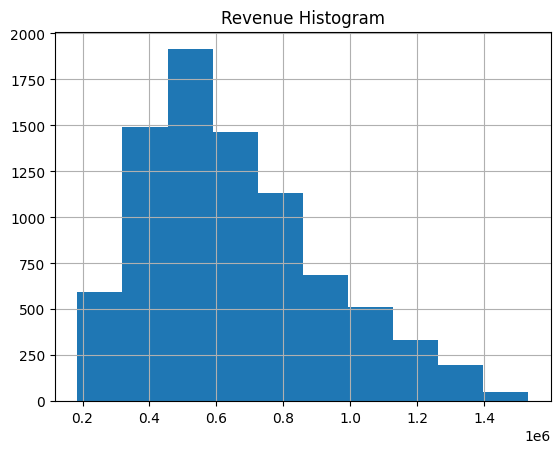

In [37]:
df["Revenue"].hist()
plt.title('Revenue Histogram')
plt.show()

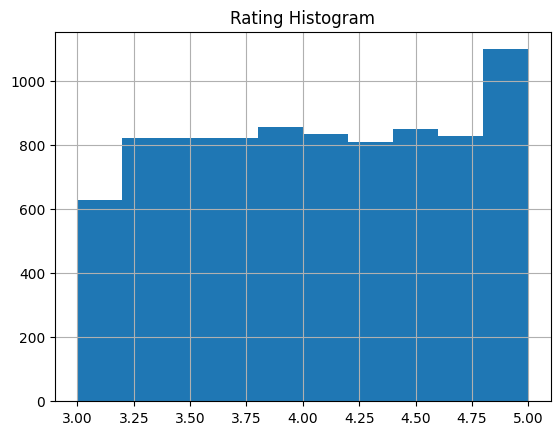

In [38]:
df["Rating"].hist()
plt.title('Rating Histogram')
plt.show()

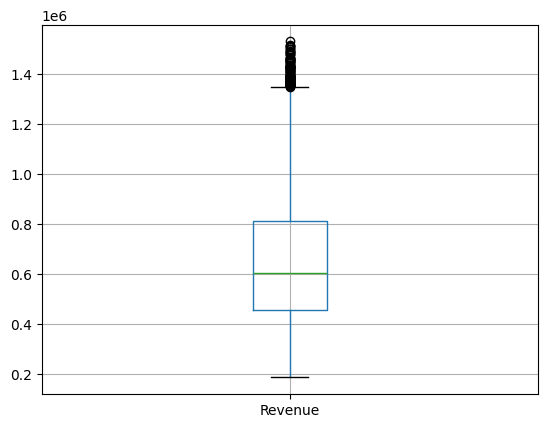

In [39]:
df.boxplot(column="Revenue")
plt.show()

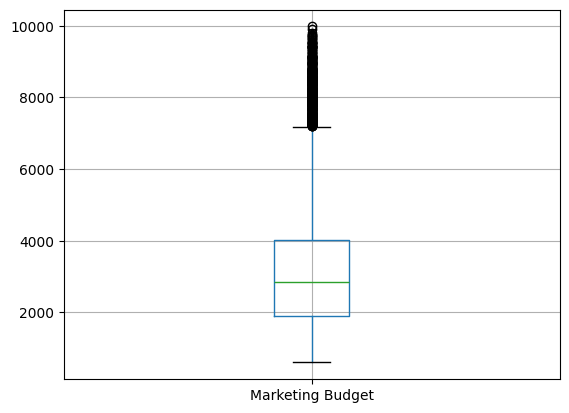

In [40]:
df.boxplot(column="Marketing Budget")
plt.show()

<Axes: xlabel='Cuisine'>

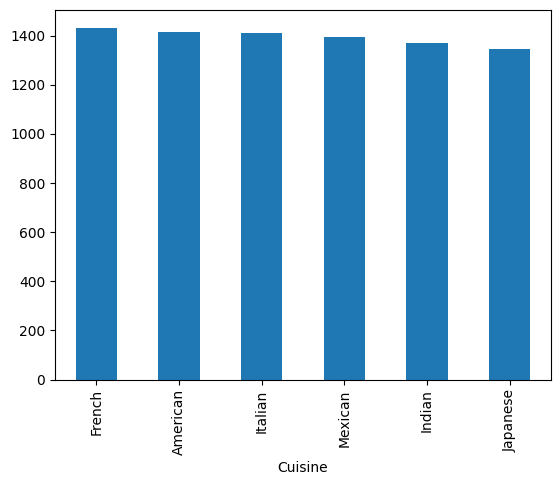

In [41]:
df["Cuisine"].value_counts().plot(kind="bar")

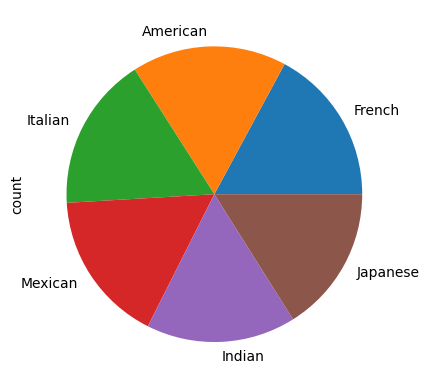

In [42]:
df["Cuisine"].value_counts().plot(kind="pie")
plt.show()

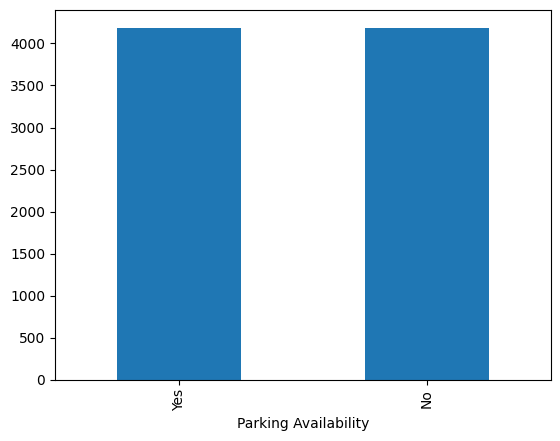

In [43]:
df["Parking Availability"].value_counts().plot(kind="bar")
plt.show()

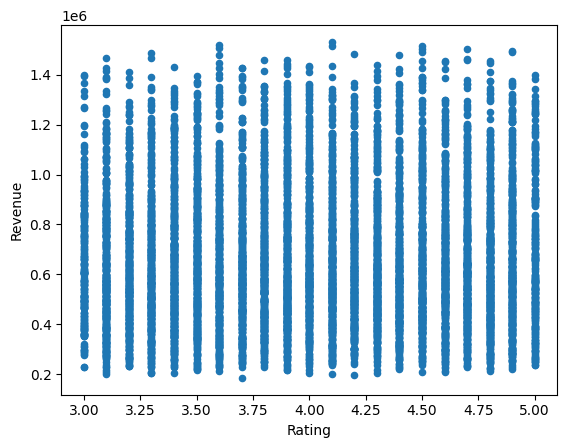

In [44]:
df.plot.scatter(
    x="Rating",
    y="Revenue"
)
plt.show()

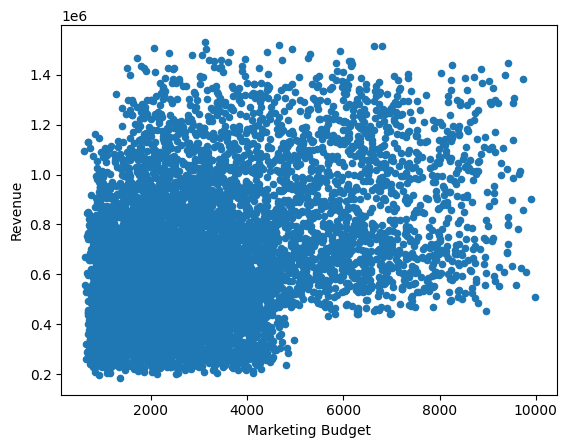

In [45]:
df.plot.scatter(
    x="Marketing Budget",
    y="Revenue"
)
plt.show()

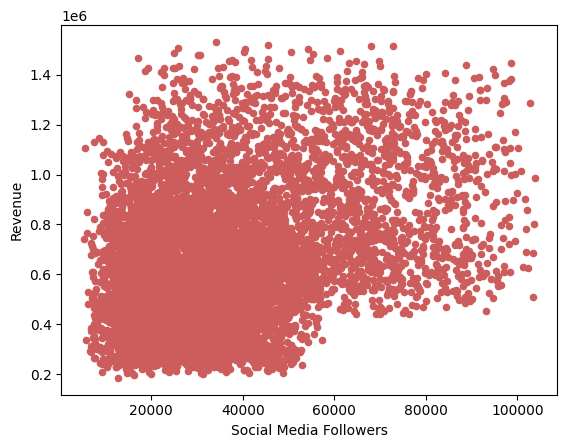

In [46]:
df.plot.scatter(
    x="Social Media Followers",
    y="Revenue",
    color="#CD5C5C"
)
plt.show()

<Axes: title={'center': 'Revenue'}, xlabel='Cuisine'>

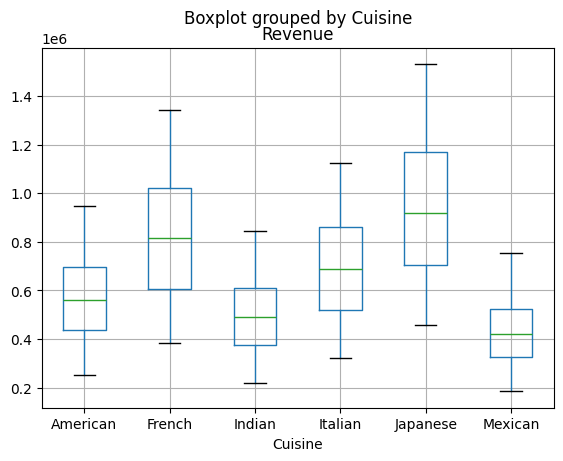

In [47]:
df.boxplot(
    column="Revenue",
    by="Cuisine"
)

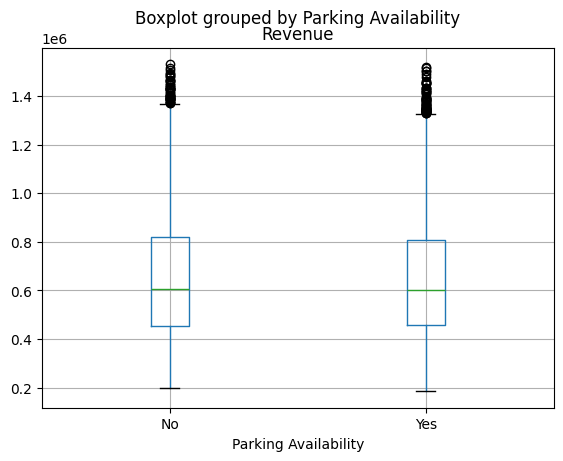

In [48]:
df.boxplot(
    column="Revenue",
    by="Parking Availability"
)
plt.show()

<Axes: xlabel='Cuisine'>

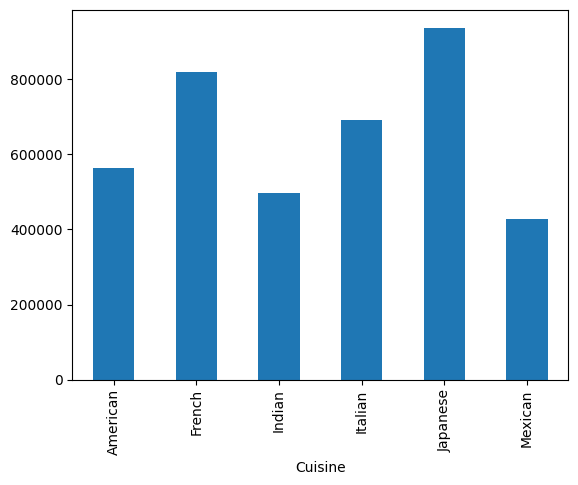

In [49]:
df.groupby("Cuisine")["Revenue"].mean().plot(kind="bar")

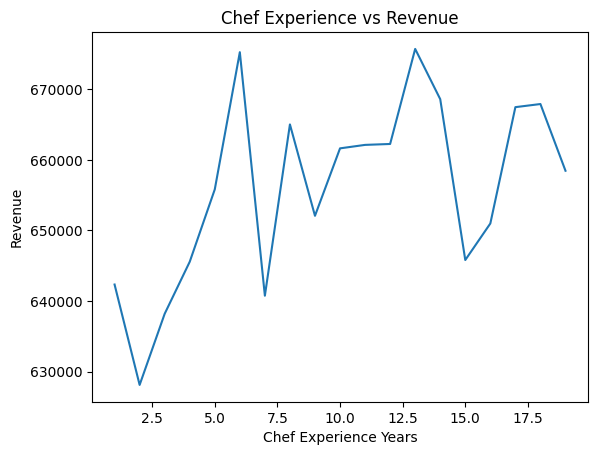

In [50]:
avg_revenue=df.groupby("Chef Experience Years")["Revenue"].mean().reset_index()
sns.lineplot(
    data=avg_revenue,
    x="Chef Experience Years",
    y="Revenue"
)
plt.title("Chef Experience vs Revenue")
plt.show()

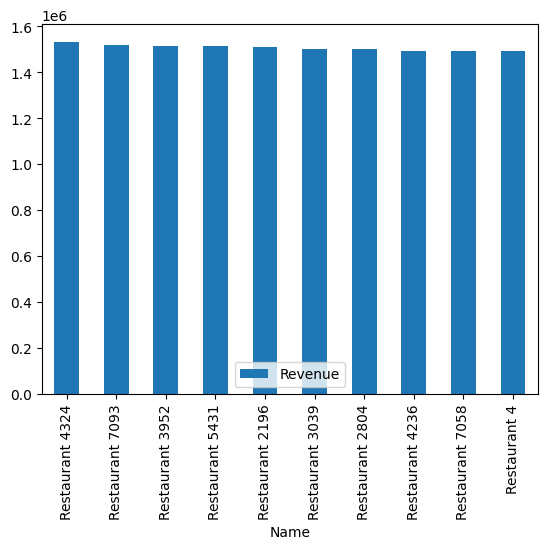

In [51]:
top10=df.sort_values("Revenue",ascending=False).head(10)
top10.plot(
    x="Name",
    y="Revenue",
    kind="bar"
)
plt.show()

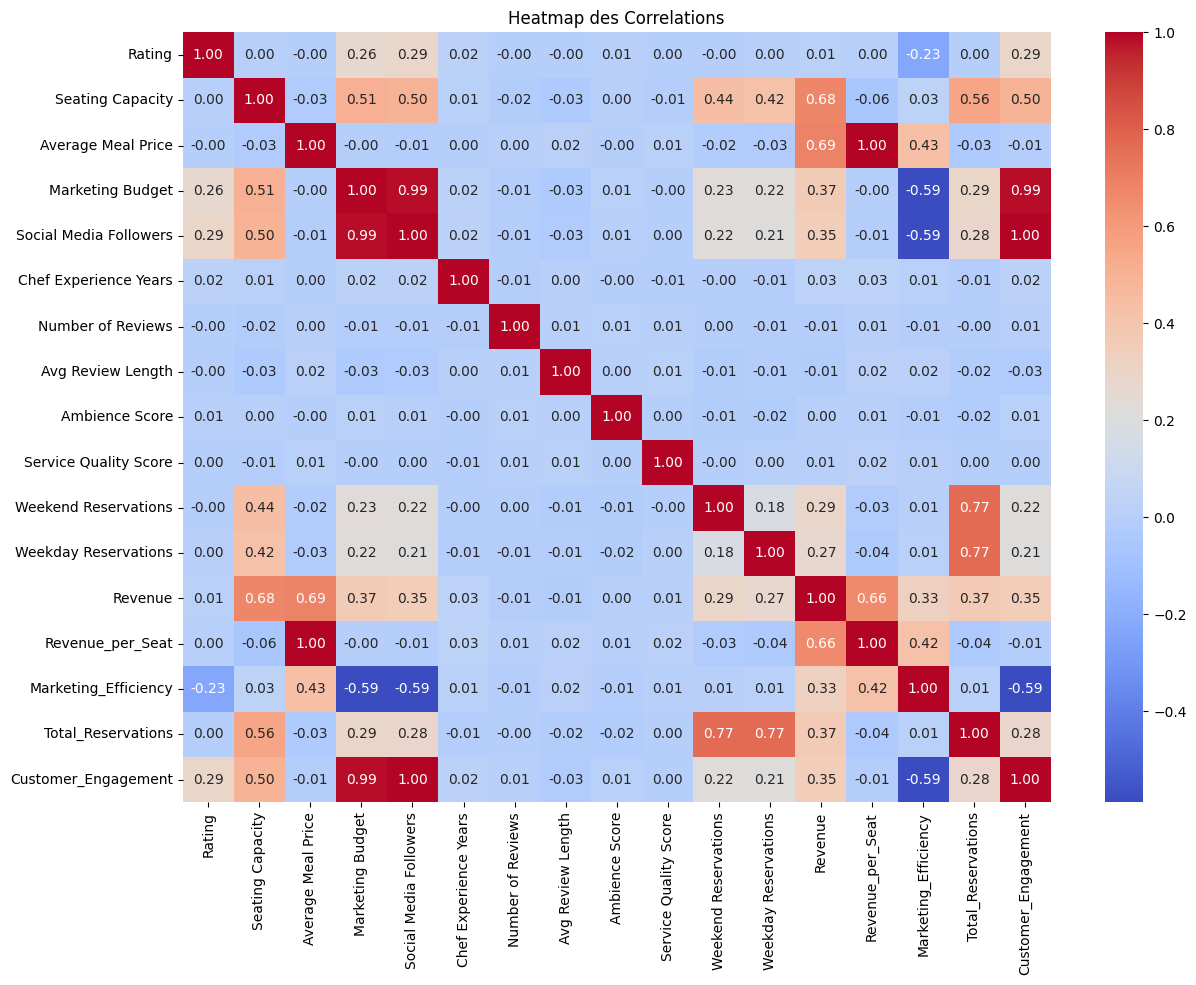

In [52]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.select_dtypes(include="number").corr(),annot=True,fmt=".2f",cmap="coolwarm"
)
plt.title("Heatmap des Correlations")
plt.show()

In [53]:
df.corr(numeric_only=True)["Revenue"]


Rating                    0.009899
Seating Capacity          0.677317
Average Meal Price        0.686365
Marketing Budget          0.365322
Social Media Followers    0.354466
Chef Experience Years     0.026899
Number of Reviews        -0.008233
Avg Review Length        -0.011278
Ambience Score            0.003388
Service Quality Score     0.005375
Weekend Reservations      0.292400
Weekday Reservations      0.273284
Revenue                   1.000000
Revenue_per_Seat          0.664249
Marketing_Efficiency      0.325785
Total_Reservations        0.368278
Customer_Engagement       0.354353
Name: Revenue, dtype: float64